# Structure Learning for MNIST with a Renormalising Generative Model

Strongly inspired by (but not a direct reproduction of) Friston et al. (2025) *From pixels to planning: scale-free active inference.* Front. Netw. Physiol. 5:1521963

In [1]:
from utils import load_mnist

x_train, y_train, x_test, y_test = load_mnist()


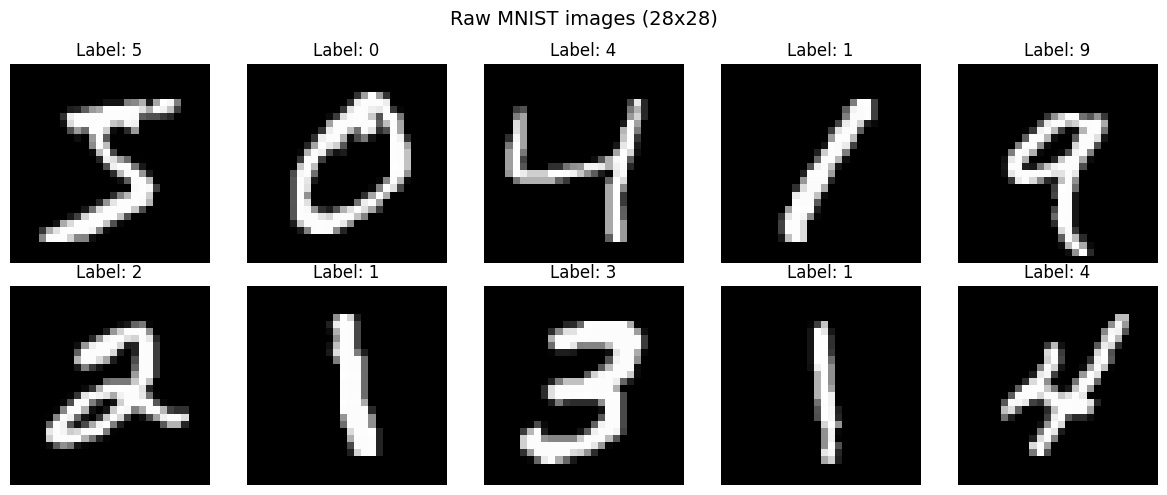

In [2]:
from matplotlib import pyplot as plt

fig, axes = plt.subplots(2, 5, figsize=(12, 5))
for i, ax in enumerate(axes.flat):
    ax.imshow(x_train[i], cmap='gray')
    ax.set_title(f'Label: {y_train[i]}')
    ax.axis('off')

fig.suptitle('Raw MNIST images (28x28)', fontsize=14)
plt.tight_layout()
plt.show()

## Select Structure Learning Exemplars
From the paper (p.10):

> Based on the prior that there can be a dozen ways of writing any given number, the first 13 (Baker's dozen) images of each digit class were used for fast structure learning.

These 130 images (13 per class x 10 classes) are used to build the initial RGM hierarchy via fast structure learning. The remaining images are used for active learning.

In [3]:
from utils import extract_exemplars

M_PER_CLASS = 13  # Baker's dozen
NUM_CLASSES = 10

x_exemplars_raw, y_exemplars, exemplar_idx = extract_exemplars(x_train, y_train, M_PER_CLASS, NUM_CLASSES)
print(f"Exemplar images: {x_exemplars_raw.shape}")
print(f"Per class: {[(y_exemplars == d).sum().item() for d in range(10)]}")

Exemplar images: (130, 28, 28)
Per class: [13, 13, 13, 13, 13, 13, 13, 13, 13, 13]


In [4]:
from preprocess import preprocess

x_exemplars = preprocess(x_exemplars_raw)
print(f"Preprocessed exemplars: {x_exemplars.shape}")

Preprocessed exemplars: (130, 32, 32)


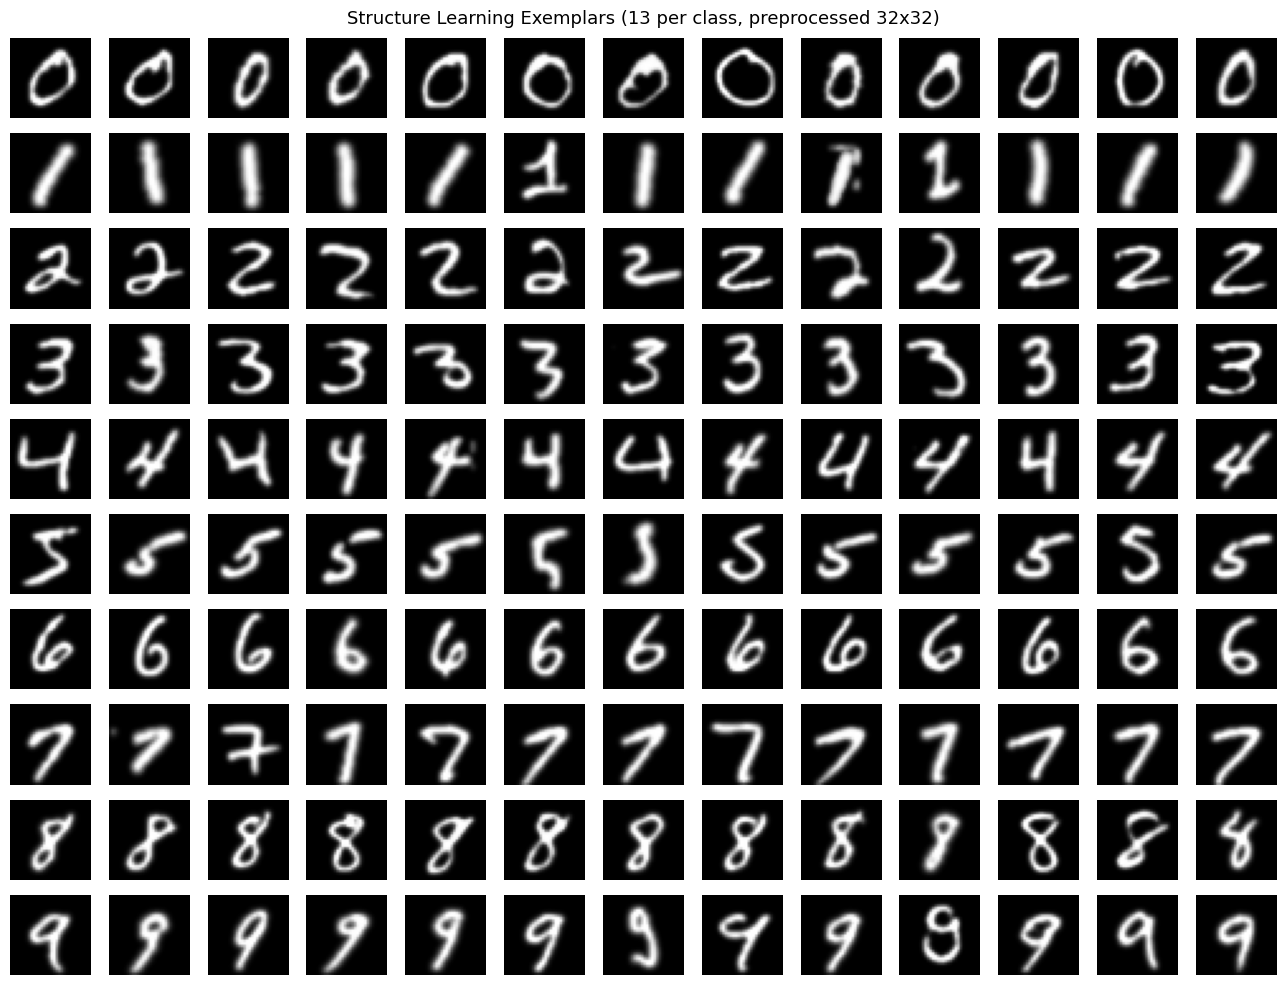

In [5]:
fig, axes = plt.subplots(NUM_CLASSES, M_PER_CLASS, figsize=(M_PER_CLASS, NUM_CLASSES))
for digit in range(NUM_CLASSES):
    mask = y_exemplars == digit
    digit_imgs = x_exemplars[mask]
    for j in range(M_PER_CLASS):
        axes[digit, j].imshow(digit_imgs[j], cmap='gray')
        axes[digit, j].axis('off')
    axes[digit, 0].set_ylabel(str(digit), rotation=0, fontsize=12, labelpad=15)
fig.suptitle(f'Structure Learning Exemplars ({M_PER_CLASS} per class, preprocessed 32x32)', fontsize=13)
plt.tight_layout()
plt.show()

## Discretisation using Singular Value Decomposition (SVD)

From the paper (p.8-10): Images are tessellated into 4x4 patches. Each patch location gets its own SVD basis learned from the structure exemplars. Continuous singular variates are quantised into 7 discrete levels, producing a discrete observation tensor per image.

The main text in the paper says:

> "Each group is then subject to singular value decomposition, given a training set of images, to identify an orthogonal (spatial) basis set of singular vectors. This grouping is followed by a reduction operator that retains singular variates with large singular values (here, the first 32 principal vectors based on groups of 4 × 4 pixels)."

> "The set of singular variates for each group specifies the pattern for any given image at the corresponding location. The continuous variates can then be quantized to a discrete number of levels (here, seven)."

However the figure 4 caption says:

> "...in this example, the singular variates could take seven discrete values centered on zero for a maximum of 16 singular vectors."

And footnote 7 says:

> "In practice, we use overlapping groups, where the singular value decomposition is applied following weighting by a radial (Gaussian) basis function whose standard deviation is the distance between group centers."

SPM alignment notes:

- SVD modes are selected adaptively via spm_svd(Y, 1/su) where su=8, retaining only modes with normalized singular values above 1/su. This is capped at mm=16 max modes.
- Bin assignment uses nearest-centre (not edge-based) matching SPM's [~, U] = min(abs(u(t,m) - a)).
- The number of retained modes varies per patch location.

Here we will use overlapping groups, as that seems sensible given the discussion points about receptive fields later in the paper. 

In [6]:
from discretise import (
    DiscretiseConfig,
    compute_svd_basis_overlapping, 
    encode_images_overlapping, 
    decode_observations_overlapping,
)

config = DiscretiseConfig()

basis = compute_svd_basis_overlapping(x_exemplars, config)
obs = encode_images_overlapping(x_exemplars, basis)
recon = decode_observations_overlapping(obs, basis)

print(f"  V shape:       {basis.V.shape}")
print(f"  Modes/patch:   min={int(basis.n_modes.min())}, max={int(basis.n_modes.max())}, mean={float(basis.n_modes.mean()):.1f}")
print(f"  MSE:           {float(((x_exemplars - recon[:, 0]) ** 2).mean()):.2f}")

  V shape:       (8, 8, 1024, 16)
  Modes/patch:   min=5, max=15, mean=11.1
  MSE:           60.65


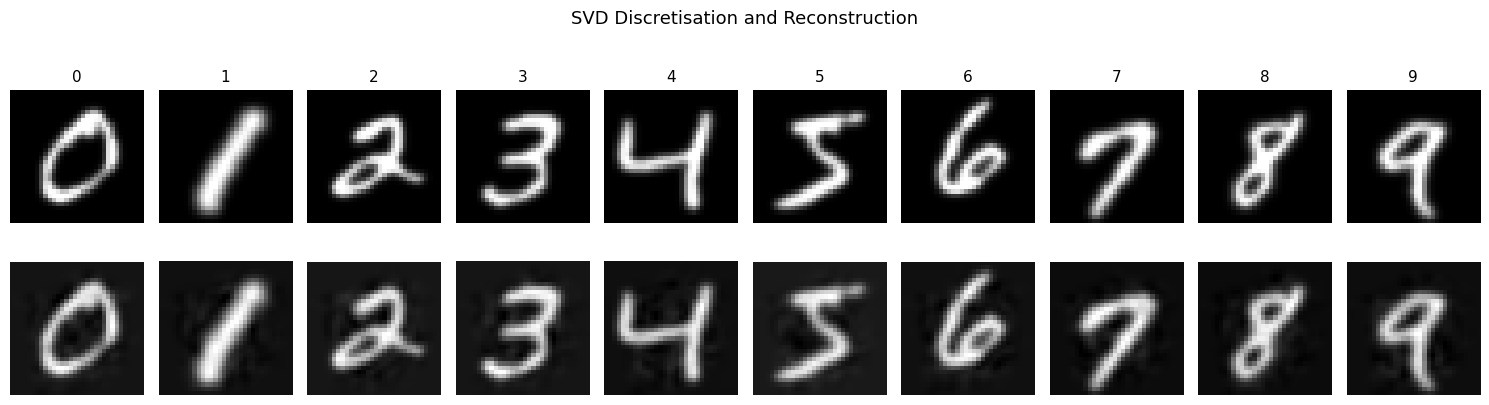

In [7]:
# Show impact of discretisation on information loss
import jax
from jax import numpy as jnp

show_idx = [jnp.where(y_exemplars == d)[0][0].item() for d in range(NUM_CLASSES)]

fig, axes = plt.subplots(2, NUM_CLASSES, figsize=(NUM_CLASSES * 1.5, 4.5))
for col, idx in enumerate(show_idx):
    axes[0, col].imshow(x_exemplars[idx], cmap='gray')
    axes[0, col].set_title(str(col), fontsize=11)
    axes[0, col].axis('off')
    axes[1, col].imshow(recon[idx, 0], cmap='gray')
    axes[1, col].axis('off')
axes[0, 0].set_ylabel('Original', fontsize=11)
axes[1, 0].set_ylabel('Overlapping', fontsize=11)
fig.suptitle('SVD Discretisation and Reconstruction', fontsize=13)
plt.tight_layout()
plt.show()

In [8]:
from rgm_hierarchy import RGMHierarchy

rgm = RGMHierarchy.from_exemplars(x_exemplars, y_exemplars, config)

/home/arun-niranjan/repos/pymdp/examples/renormalising_generative_models/agent_build.py:65: UserWarning: A JAX array is being set as static! This can result in unexpected behavior and is usually a mistake to do.
  return Agent(


In [9]:
import numpy as np

# Hierarchy summary
print(f"Number of levels: {len(rgm.levels)} ({len(rgm.hierarchical_levels)} hierarchical + 1 classification)")
for lv, level in enumerate(rgm.hierarchical_levels):
    grid = level.stats.num_states
    n_grid = grid.shape[0]
    print(f"  L{lv+1}: {n_grid}x{n_grid} grid, "
          f"states/location: {int(grid.min())}-{int(grid.max())} "
          f"(mean {float(grid.mean()):.1f})")

# Classification level: P(top_state | digit) from the cls_agent's A matrix
n_top = int(rgm.hierarchical_levels[-1].stats.num_states[0, 0])
cls_A = np.asarray(rgm.cls_agent.A[0][0])  # (n_top_states, n_classes)
print(f"\nTop-level states: {n_top}")
print(f"Classification level: {n_top} states -> {rgm.n_classes} digit classes")
for d in range(rgm.n_classes):
    col = cls_A[:, d]
    n_active = (col > 0).sum()
    top3 = np.argsort(col)[::-1][:3]
    top3_str = ", ".join(f"s{s}({col[s]:.2f})" for s in top3)
    print(f"  Digit {d}: {n_active} contributing states, top: {top3_str}")

Number of levels: 4 (3 hierarchical + 1 classification)
  L1: 4x4 grid, states/location: 33-130 (mean 107.0)
  L2: 2x2 grid, states/location: 130-130 (mean 130.0)
  L3: 1x1 grid, states/location: 130-130 (mean 130.0)

Top-level states: 130
Classification level: 130 states -> 10 digit classes
  Digit 0: 13 contributing states, top: s102(0.08), s96(0.08), s17(0.08)
  Digit 1: 13 contributing states, top: s115(0.08), s113(0.08), s79(0.08)
  Digit 2: 13 contributing states, top: s122(0.08), s124(0.08), s6(0.08)
  Digit 3: 13 contributing states, top: s129(0.08), s127(0.08), s25(0.08)
  Digit 4: 13 contributing states, top: s128(0.08), s125(0.08), s4(0.08)
  Digit 5: 13 contributing states, top: s76(0.08), s106(0.08), s78(0.08)
  Digit 6: 13 contributing states, top: s99(0.08), s103(0.08), s41(0.08)
  Digit 7: 13 contributing states, top: s119(0.08), s126(0.08), s22(0.08)
  Digit 8: 13 contributing states, top: s83(0.08), s101(0.08), s31(0.08)
  Digit 9: 13 contributing states, top: s105(0.

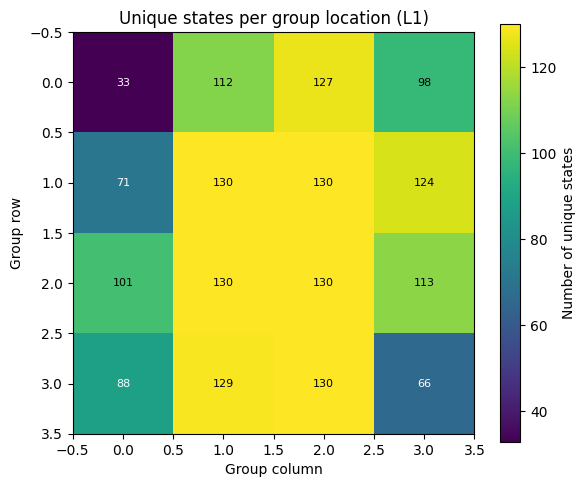

In [10]:
# Group state count heatmap (Level 1)
l1_stats = rgm.levels[0].stats

fig, ax = plt.subplots(1, 1, figsize=(6, 5))
im = ax.imshow(l1_stats.num_states, cmap='viridis')
ax.set_title('Unique states per group location (L1)')
ax.set_xlabel('Group column')
ax.set_ylabel('Group row')
for i in range(l1_stats.num_states.shape[0]):
    for j in range(l1_stats.num_states.shape[1]):
        ax.text(j, i, int(l1_stats.num_states[i, j]), ha='center', va='center',
                color='white' if l1_stats.num_states[i, j] < l1_stats.num_states.max() * 0.7 else 'black',
                fontsize=8)
fig.colorbar(im, ax=ax, label='Number of unique states')
plt.tight_layout()
plt.show()

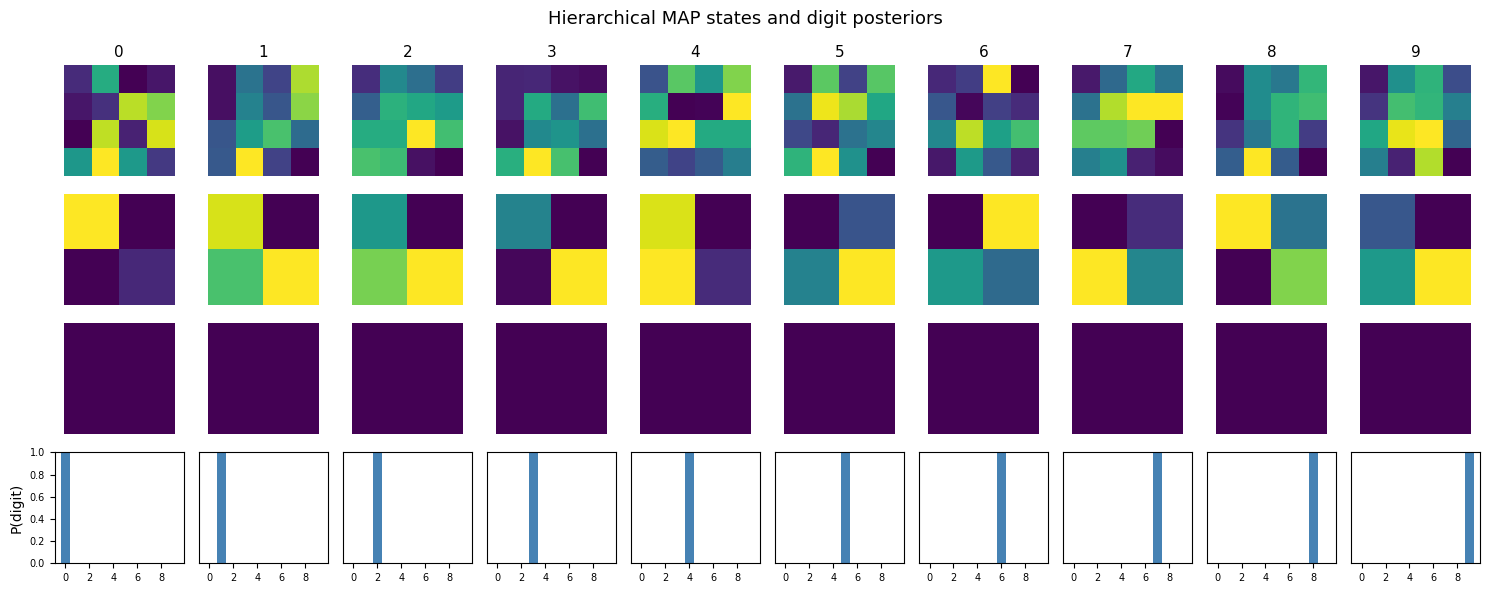

In [11]:
from hierarchical import infer_hierarchical_states
from agent_build import _infer_beliefs, _infer_map_states
from group_agents import _raw_obs_to_group_obs_list
from discretise import encode_images_overlapping

# Encode exemplars and pick one image per digit
observations = encode_images_overlapping(x_exemplars, rgm.basis)
show_idx = [jnp.where(y_exemplars == d)[0][0].item() for d in range(NUM_CLASSES)]

hier_levels = rgm.hierarchical_levels
n_hier = len(hier_levels)
n_rows = n_hier + 1  # hierarchical levels + classification row

fig, axes = plt.subplots(n_rows, NUM_CLASSES, figsize=(NUM_CLASSES * 1.5, n_rows * 1.5))
for col, idx in enumerate(show_idx):
    # L1: group-level inference over joint 4-tile SVD observations
    ng2 = observations[idx].shape[0] // 2
    obs_list = _raw_obs_to_group_obs_list(observations[idx])
    maps = _infer_map_states(hier_levels[0].agent, hier_levels[0].valid_mask,
                            obs_list, output_shape=(ng2, ng2))
    axes[0, col].imshow(maps, cmap='viridis')
    axes[0, col].set_title(str(col), fontsize=11)
    axes[0, col].axis('off')
    # L2+: hierarchical inference
    for lv, level in enumerate(hier_levels[1:], 1):
        maps = infer_hierarchical_states(level.agent, level.valid_mask, maps)
        axes[lv, col].imshow(maps, cmap='viridis')
        axes[lv, col].axis('off')
    # Classification level: digit posterior as a bar chart
    s_top = int(maps[0, 0])
    obs_list_cls = [jax.nn.one_hot(jnp.array([s_top]), rgm.cls_agent.num_obs[0])]
    beliefs = _infer_beliefs(rgm.cls_agent, rgm.cls_valid_mask, obs_list_cls)[0]
    axes[n_hier, col].bar(range(rgm.n_classes), beliefs, color='steelblue')
    axes[n_hier, col].set_ylim(0, 1)
    axes[n_hier, col].set_xticks(range(0, 10, 2))
    axes[n_hier, col].tick_params(labelsize=7)
    if col > 0:
        axes[n_hier, col].set_yticks([])

for lv in range(n_hier):
    grid_size = hier_levels[lv].stats.num_states.shape[0]
    axes[lv, 0].set_ylabel(f'L{lv+1} ({grid_size}x{grid_size})', fontsize=10)
axes[n_hier, 0].set_ylabel('P(digit)', fontsize=10)

fig.suptitle('Hierarchical MAP states and digit posteriors', fontsize=13)
plt.tight_layout()
plt.show()

## Classification
The `RGMHierarchy.classify` method runs bottom-up inference on unseen images to produce a digit prediction.

In [12]:
# Sanity check: classify the 130 structure exemplars (should be 100%)
pred_exemplars, top_exemplars, digit_beliefs = rgm.classify(x_exemplars)
exemplar_acc = (pred_exemplars == np.array(y_exemplars)).mean()
print(f"Structure exemplar accuracy: {exemplar_acc:.1%} ({(pred_exemplars == np.array(y_exemplars)).sum()}/{len(y_exemplars)})")
if exemplar_acc < 1.0:
    mismatches = np.where(pred_exemplars != np.array(y_exemplars))[0]
    for idx in mismatches[:10]:
        print(f"  Image {idx}: true={y_exemplars[idx]}, pred={pred_exemplars[idx]}, top state={top_exemplars[idx]}")

Structure exemplar accuracy: 100.0% (130/130)


Test accuracy (1000 images): 56.9%
  Digit 0: 62.4% (53/85)
  Digit 1: 98.4% (124/126)
  Digit 2: 62.1% (72/116)
  Digit 3: 57.9% (62/107)
  Digit 4: 62.7% (69/110)
  Digit 5: 25.3% (22/87)
  Digit 6: 64.4% (56/87)
  Digit 7: 52.5% (52/99)
  Digit 8: 33.7% (30/89)
  Digit 9: 30.9% (29/94)


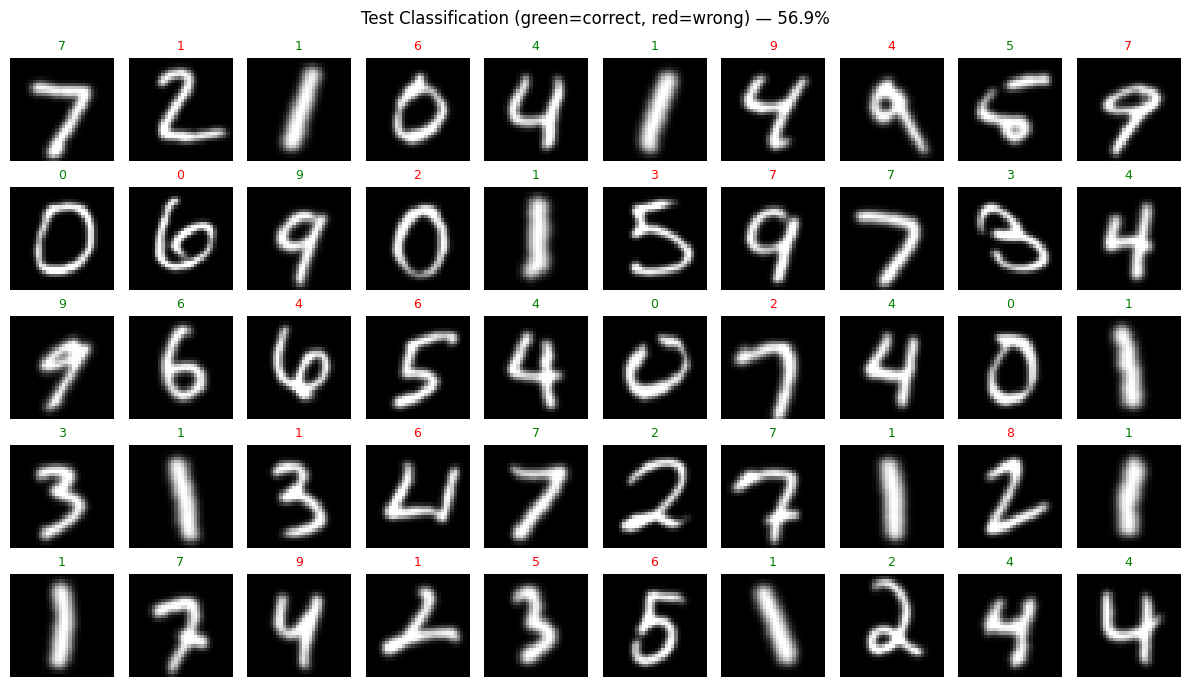

In [13]:
# Classify first 1000 test images
N_TEST = 1000
x_test_pre = preprocess(x_test[:N_TEST])
y_test_sub = np.array(y_test[:N_TEST])

pred_test, top_test, digit_beliefs = rgm.classify(x_test_pre)
test_acc = (pred_test == y_test_sub).mean()
print(f"Test accuracy ({N_TEST} images): {test_acc:.1%}")

# Per-digit accuracy
for d in range(10):
    mask = y_test_sub == d
    if mask.sum() > 0:
        d_acc = (pred_test[mask] == d).mean()
        print(f"  Digit {d}: {d_acc:.1%} ({(pred_test[mask] == d).sum()}/{mask.sum()})")

# Show grid with color-coded predictions
n_show = min(50, N_TEST)
cols = 10
rows = (n_show + cols - 1) // cols
fig, axes = plt.subplots(rows, cols, figsize=(cols * 1.2, rows * 1.4))
for i, ax in enumerate(axes.flat):
    if i < n_show:
        ax.imshow(np.array(x_test_pre[i]), cmap='gray')
        correct = pred_test[i] == y_test_sub[i]
        color = 'green' if correct else 'red'
        ax.set_title(f"{pred_test[i]}", fontsize=9, color=color)
    ax.axis('off')
fig.suptitle(f'Test Classification (green=correct, red=wrong) — {test_acc:.1%}', fontsize=12)
plt.tight_layout()
plt.show()

## Active Learning (Parametric Training with Bidirectional Message Passing)

Following the SPM reference (`DEM_MNIST_RGM.m`), we refine all A matrices by processing training images sequentially. For each image:

1. **Bottom-up pass**: inference runs level by level with default D priors, producing soft beliefs at each level
2. **Classification**: inference with a supervised one-hot D prior (true label), giving the digit posterior
3. **Top-down pass**: the classification posterior is propagated back down — each level's beliefs are refined using top-down predictions from the level above as D priors
4. **Dirichlet updates**: all levels update their A matrices using the top-down corrected beliefs

This bidirectional scheme matches SPM's `FIX.A=0` setting, with initial Dirichlet concentrations `1/16` for hierarchical levels and `1/128` for the classification level.

In [14]:
# Preprocess full training set
x_train_pre = preprocess(x_train)
print(f"Training images: {x_train_pre.shape}")

Training images: (60000, 32, 32)


In [15]:
N_TRAIN = 10000

metrics = rgm.train(
    x_train_pre[:N_TRAIN],
    np.array(y_train[:N_TRAIN]),
    concentration_lower=1 / 16,
    concentration_cls=1 / 128,
    lr_pA=1.0,
    beta=512.0,
    eta=512.0,
    log_every=200,
    scan_chunk_size=50,
)

  [200/10000] acc=0.900  MI: L1=579.076  L2=8.979  L3=1.964  cls=1.786
  [400/10000] acc=0.790  MI: L1=581.568  L2=14.134  L3=2.750  cls=1.810
  [600/10000] acc=0.778  MI: L1=582.447  L2=18.900  L3=3.597  cls=1.869
  [800/10000] acc=0.774  MI: L1=583.007  L2=22.991  L3=4.347  cls=1.878
  [1000/10000] acc=0.765  MI: L1=584.326  L2=26.349  L3=5.077  cls=1.890
  [1200/10000] acc=0.762  MI: L1=585.296  L2=29.005  L3=5.671  cls=1.873
  [1400/10000] acc=0.760  MI: L1=585.545  L2=30.806  L3=6.220  cls=1.862
  [1600/10000] acc=0.763  MI: L1=586.454  L2=32.484  L3=6.813  cls=1.875
  [1800/10000] acc=0.773  MI: L1=586.906  L2=34.220  L3=7.348  cls=1.894
  [2000/10000] acc=0.778  MI: L1=587.033  L2=35.280  L3=7.801  cls=1.892
  [2200/10000] acc=0.780  MI: L1=587.061  L2=36.168  L3=8.174  cls=1.893
  [2400/10000] acc=0.785  MI: L1=587.458  L2=36.988  L3=8.618  cls=1.909
  [2600/10000] acc=0.787  MI: L1=587.786  L2=37.502  L3=8.906  cls=1.920
  [2800/10000] acc=0.789  MI: L1=588.373  L2=38.169  L3=

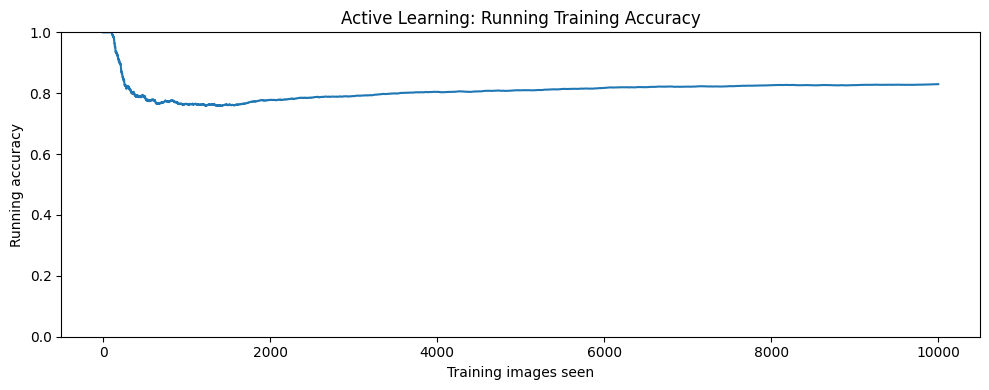

In [16]:
# Plot running training accuracy
fig, ax = plt.subplots(figsize=(10, 4))
ax.plot(metrics["running_accuracy"])
ax.set_xlabel("Training images seen")
ax.set_ylabel("Running accuracy")
ax.set_title("Active Learning: Running Training Accuracy")
ax.set_ylim(0, 1)
plt.tight_layout()
plt.show()

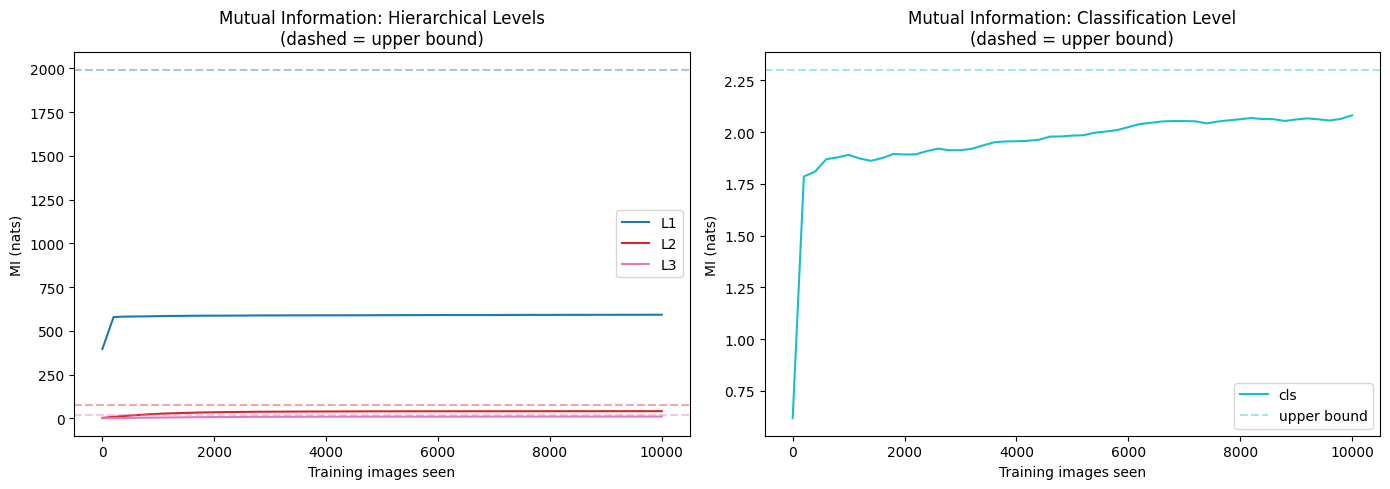

Level       MI (init)   MI (final)   Upper bound   % of max
----------------------------------------------------------
L1           396.1816     592.2710     1992.6120      29.7%
L2             3.1760      41.5065       77.8806      53.3%
L3             0.8553      10.7233       19.4701      55.1%
cls            0.6174       2.0814        2.3026      90.4%


In [17]:
from mutual_information import compute_level_mi

# Plot mutual information per level over training
# Following spm_MDP_MI: I(o; s) = H(o) + H(s) - H(o,s) computed on normalised Dirichlet params
mi_arr = np.array(metrics["mi_history"])          # (n_checkpoints, n_levels)
checkpoints = metrics["mi_checkpoints"]
upper_bounds = metrics["mi_upper_bounds"]
n_levels = mi_arr.shape[1]
n_hier = len(rgm.hierarchical_levels)

level_names = [f"L{i+1}" for i in range(n_hier)] + ["cls"]
colors = plt.cm.tab10(np.linspace(0, 1, n_levels))

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Left: all hierarchical levels
ax = axes[0]
for i in range(n_hier):
    ax.plot(checkpoints, mi_arr[:, i], color=colors[i], label=level_names[i])
    ax.axhline(upper_bounds[i], color=colors[i], linestyle='--', alpha=0.4)
ax.set_xlabel("Training images seen")
ax.set_ylabel("MI (nats)")
ax.set_title("Mutual Information: Hierarchical Levels\n(dashed = upper bound)")
ax.legend()

# Right: classification level
ax = axes[1]
ax.plot(checkpoints, mi_arr[:, -1], color=colors[-1], label="cls")
ax.axhline(upper_bounds[-1], color=colors[-1], linestyle='--', alpha=0.4, label="upper bound")
ax.set_xlabel("Training images seen")
ax.set_ylabel("MI (nats)")
ax.set_title("Mutual Information: Classification Level\n(dashed = upper bound)")
ax.legend()

plt.tight_layout()
plt.show()

# Print summary table
print(f"{'Level':<8} {'MI (init)':>12} {'MI (final)':>12} {'Upper bound':>13} {'% of max':>10}")
print("-" * 58)
for i, name in enumerate(level_names):
    print(f"{name:<8} {mi_arr[0, i]:>12.4f} {mi_arr[-1, i]:>12.4f} {upper_bounds[i]:>13.4f} "
          f"{100 * mi_arr[-1, i] / upper_bounds[i]:>9.1f}%")

In [18]:
# Re-evaluate on test set after active learning
pred_post, _, beliefs_post = rgm.classify(x_test_pre)
acc_post = (pred_post == y_test_sub).mean()
print(f"Test accuracy BEFORE training: {test_acc:.1%}")
print(f"Test accuracy AFTER  training: {acc_post:.1%}")

# Per-digit breakdown
print()
for d in range(10):
    mask = y_test_sub == d
    if mask.sum() > 0:
        before = (pred_test[mask] == d).mean()
        after = (pred_post[mask] == d).mean()
        print(f"  Digit {d}: {before:.1%} → {after:.1%}")

Test accuracy BEFORE training: 56.9%
Test accuracy AFTER  training: 84.9%

  Digit 0: 62.4% → 91.8%
  Digit 1: 98.4% → 97.6%
  Digit 2: 62.1% → 80.2%
  Digit 3: 57.9% → 86.9%
  Digit 4: 62.7% → 76.4%
  Digit 5: 25.3% → 77.0%
  Digit 6: 64.4% → 95.4%
  Digit 7: 52.5% → 83.8%
  Digit 8: 33.7% → 75.3%
  Digit 9: 30.9% → 83.0%


In [19]:
# Compare: MNIST test set vs MATLAB-equivalent validation slice
#
# MATLAB evaluates on training images 10001-11000 (test = (1:T) + N, T=1000, N=10000).
# Python evaluates on the held-out MNIST test set (60001-70000).
# This cell runs both evaluations so the two numbers are directly comparable.

T_MATLAB = 1000                                   # same as MATLAB
x_matlab_val_raw = x_train[10000:10000 + T_MATLAB]
y_matlab_val     = np.array(y_train[10000:10000 + T_MATLAB])
x_matlab_val     = preprocess(x_matlab_val_raw)

pred_matlab_val, _, _ = rgm.classify(x_matlab_val)
acc_matlab_val = (pred_matlab_val == y_matlab_val).mean()

# MNIST test set (already evaluated)
print(f"Accuracy on MNIST test set (images 60001-61000):   {acc_post:.1%}  [Python evaluates here]")
print(f"Accuracy on training images 10001-11000:           {acc_matlab_val:.1%}  [MATLAB evaluates here]")
print()
print("Note: MATLAB's reported ~95% uses the in-distribution training slice.")
print("The MNIST test set is the proper held-out benchmark.")

Accuracy on MNIST test set (images 60001-61000):   84.9%  [Python evaluates here]
Accuracy on training images 10001-11000:           86.9%  [MATLAB evaluates here]

Note: MATLAB's reported ~95% uses the in-distribution training slice.
The MNIST test set is the proper held-out benchmark.


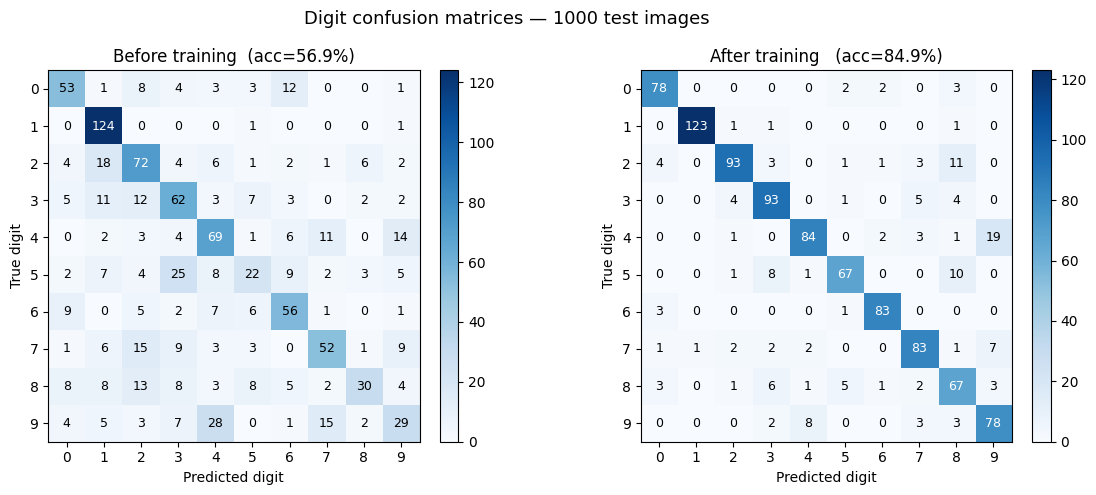

In [20]:
# ── Confusion matrices: pre vs post training ─────────────────────────────────
from sklearn.metrics import confusion_matrix

cm_pre  = confusion_matrix(y_test_sub, pred_test, labels=list(range(NUM_CLASSES)))
cm_post = confusion_matrix(y_test_sub, pred_post, labels=list(range(NUM_CLASSES)))

fig, axes = plt.subplots(1, 2, figsize=(12, 5))

for ax, cm, title, acc in [
    (axes[0], cm_pre,  f'Before training  (acc={test_acc:.1%})',  test_acc),
    (axes[1], cm_post, f'After training   (acc={acc_post:.1%})', acc_post),
]:
    im = ax.imshow(cm, cmap='Blues')
    ax.set_title(title, fontsize=12)
    ax.set_xlabel('Predicted digit')
    ax.set_ylabel('True digit')
    ax.set_xticks(range(NUM_CLASSES))
    ax.set_yticks(range(NUM_CLASSES))
    thresh = cm.max() / 2
    for i in range(NUM_CLASSES):
        for j in range(NUM_CLASSES):
            ax.text(j, i, str(cm[i, j]),
                    ha='center', va='center', fontsize=9,
                    color='white' if cm[i, j] > thresh else 'black')
    plt.colorbar(im, ax=ax, fraction=0.046, pad=0.04)

fig.suptitle(f"Digit confusion matrices — {N_TEST} test images", fontsize=13)
plt.tight_layout()
plt.show()


## Top-Down Generation

The `RGMHierarchy.generate` method runs the inverse of classification: starting from a
prior over digit classes, it propagates beliefs down through the hierarchy using the
learned A matrices to reconstruct an expected image.

The distributional path (`sample=False`, default) computes the *expected* reconstruction
under the full class-conditional posterior. Each level marginalises the parent's belief
over its children, so the output is a smoothed average rather than a sharp sample. This
path uses the trained A matrices at every level — comparing before and after training
shows how active learning reshapes the model's internal generative representations.

/home/arun-niranjan/repos/pymdp/examples/renormalising_generative_models/agent_build.py:65: UserWarning: A JAX array is being set as static! This can result in unexpected behavior and is usually a mistake to do.
  return Agent(


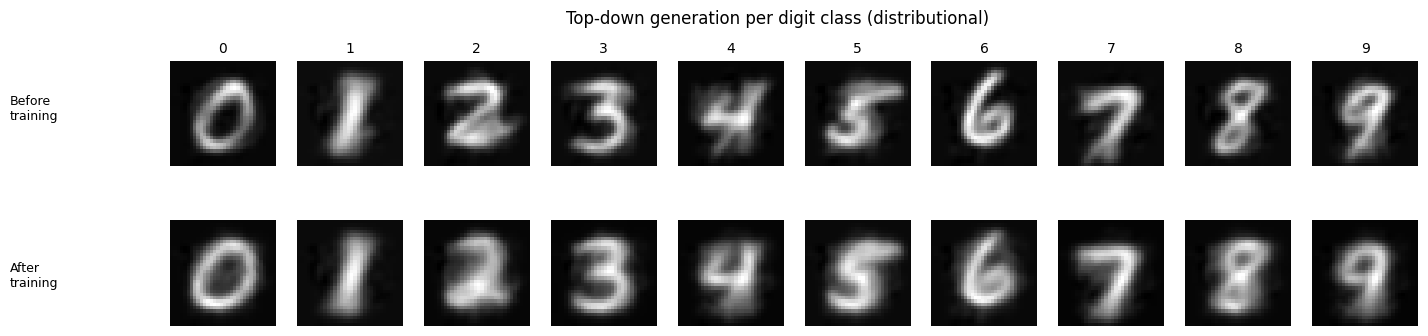

In [21]:
rgm_fresh = RGMHierarchy.from_exemplars(x_exemplars, y_exemplars, config)

def norm(img):
    mn, mx = img.min(), img.max()
    return (img - mn) / max(float(mx - mn), 1e-8)

fig, axes = plt.subplots(2, NUM_CLASSES, figsize=(NUM_CLASSES * 1.6, 3.8))
fig.subplots_adjust(left=0.12)

for d in range(NUM_CLASSES):
    img_before, _ = rgm_fresh.generate(digit=d)  # structure-learned A only
    img_after, _  = rgm.generate(digit=d)         # A refined by active learning

    axes[0, d].imshow(norm(np.array(img_before[0, 0])), cmap='gray', vmin=0, vmax=1)
    axes[0, d].set_title(str(d), fontsize=10)
    axes[0, d].axis('off')

    axes[1, d].imshow(norm(np.array(img_after[0, 0])), cmap='gray', vmin=0, vmax=1)
    axes[1, d].axis('off')

fig.text(0.02, 0.72, 'Before\ntraining', ha='left', va='center', fontsize=9)
fig.text(0.02, 0.28, 'After\ntraining',  ha='left', va='center', fontsize=9)

fig.suptitle('Top-down generation per digit class (distributional)', fontsize=12)
plt.show()